<a href="https://colab.research.google.com/github/eetyiop/computational-physics-housing-project/blob/main/housing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_housing_project_data.xlsx to cleaned_housing_project_data.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

file_name = "cleaned_housing_project_data.xlsx"

xls = pd.ExcelFile(file_name)
xls.sheet_names

['README',
 'Population_Trend',
 'Population_Region_2015_2024',
 'Price_Index_2015_2024',
 'Merged_2015_2024',
 'National_2015_2024',
 'Regional_Change_2015_2024']

In [ ]:
pop_trend = pd.read_excel(file_name, sheet_name="Population_Trend")
merged = pd.read_excel(file_name, sheet_name="Merged_2015_2024")
regional_change = pd.read_excel(file_name, sheet_name="Regional_Change_2015_2024")

print("Population trend:", pop_trend.shape)
print("Merged data:", merged.shape)
print("Regional change:", regional_change.shape)

display(pop_trend.head())
display(merged.head())
display(regional_change.head())

Population trend: (12, 7)
Merged data: (170, 11)
Regional change: (17, 11)


,Year,Region,Total_Population,Korean_Population,Foreign_Population,General_Households,Apartment_Count
0,2005,전국,47278951,47041434,237517,15887128,6962689
1,2010,전국,48580293,47990761,589532,17339422,8576013
2,2015,전국,51069375,49705663,1363712,19111030,9806062
3,2016,전국,51269554,49855796,1413758,19367696,10029644
4,2017,전국,51422507,49943260,1479247,19673875,10375363


,Year,Region,Total_Population,Korean_Population,Foreign_Population,General_Households,Apartment_Count,Korean_Population_Million,General_Households_Million,Apartment_Price_Index,Weeks_Used
0,2015,서울,9904312,9567196,337116,3784490,1636896,9.567196,3.784490,73.9519,52
1,2015,부산,3448737,3404667,44070,1335900,738068,3.404667,1.335900,95.5040,52
2,2015,대구,2466052,2436770,29282,928528,509068,2.436770,0.928528,112.2133,52
3,2015,인천,2890451,2822601,67850,1045417,577346,2.822601,1.045417,83.7160,52
4,2015,광주,1502881,1481289,21592,567157,376731,1.481289,0.567157,93.3154,52


,Region,Korean_Population_Change_Pct,General_Households_Change_Pct,Apartment_Price_Index_Change_Pct,Apartment_Price_Index_Change_Point,Pop_2015,Pop_2024,Households_2015,Households_2024,Price_Index_2015,Price_Index_2024
0,서울,-6.2614,9.9092,19.3834,14.3344,9567196,8968153,3784490,4159502,73.9519,88.2863
1,부산,-6.3199,10.0802,6.9868,6.6727,3404667,3189494,1335900,1470562,95.5040,102.1767
2,대구,-4.6262,12.4068,-4.8159,-5.4041,2436770,2324040,928528,1043729,112.2133,106.8092
3,인천,3.8076,21.3040,19.1414,16.0244,2822601,2930073,1045417,1268133,83.7160,99.7404
4,광주,-4.9281,10.8249,10.1228,9.4461,1481289,1408289,567157,628551,93.3154,102.7615


In [ ]:
os.makedirs("figures", exist_ok=True)

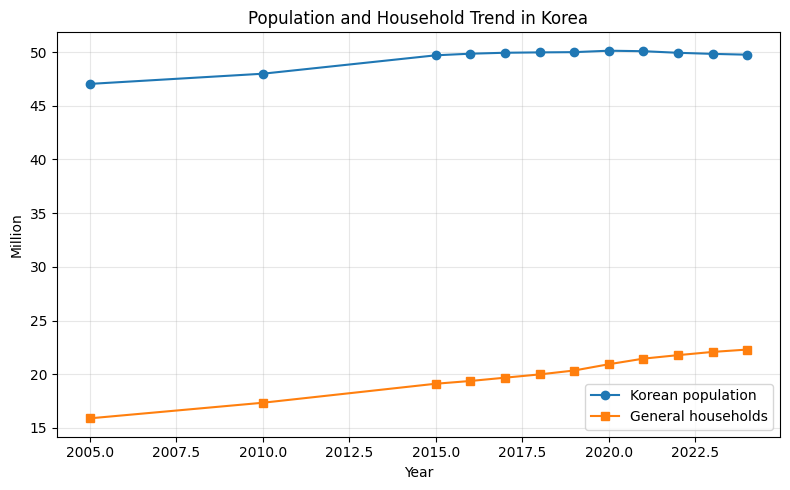

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    pop_trend["Year"],
    pop_trend["Korean_Population"] / 1_000_000,
    marker="o",
    label="Korean population"
)

plt.plot(
    pop_trend["Year"],
    pop_trend["General_Households"] / 1_000_000,
    marker="s",
    label="General households"
)

plt.xlabel("Year")
plt.ylabel("Million")
plt.title("Population and Household Trend in Korea")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("figures/01_population_trend.png", dpi=300)
plt.show()

In [ ]:
# Figure 2: Select regions by correlation
# x = general households
# y = apartment price index
# period = 2015-2024

region_results = []

for region in merged["Region"].unique():
    temp = merged[merged["Region"] == region].sort_values("Year")

    x = temp["General_Households"].values
    y = temp["Apartment_Price_Index"].values

    # correlation
    r = np.corrcoef(x, y)[0, 1]

    # linear fitting slope
    slope, intercept = np.polyfit(x, y, 1)

    region_results.append([region, r, slope])

region_result = pd.DataFrame(
    region_results,
    columns=["Region", "Correlation_r", "Slope"]
)

# Selection criterion
selected_region_result = region_result[
    (region_result["Correlation_r"] > 0.7) &
    (region_result["Slope"] > 0)
].copy()

selected_region_result = selected_region_result.sort_values(
    "Correlation_r",
    ascending=False
)

print("Selected regions:")
display(selected_region_result)

selected_regions = selected_region_result["Region"].tolist()
print(selected_regions)

Selected regions:


,Region,Correlation_r,Slope
5,대전,0.888990,0.000482
8,경기,0.830134,0.000021
4,광주,0.801528,0.000194
16,제주,0.796768,0.000310
3,인천,0.774338,0.000106
0,서울,0.725708,0.000032


['대전', '경기', '광주', '제주', '인천', '서울']


/tmp/ipykernel_3105/730731312.py:20: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3105/730731312.py:20: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3105/730731312.py:20: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3105/730731312.py:20: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3105/730731312.py:20: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3105/730731312.py:20: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3105/730731312.py:20: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layou

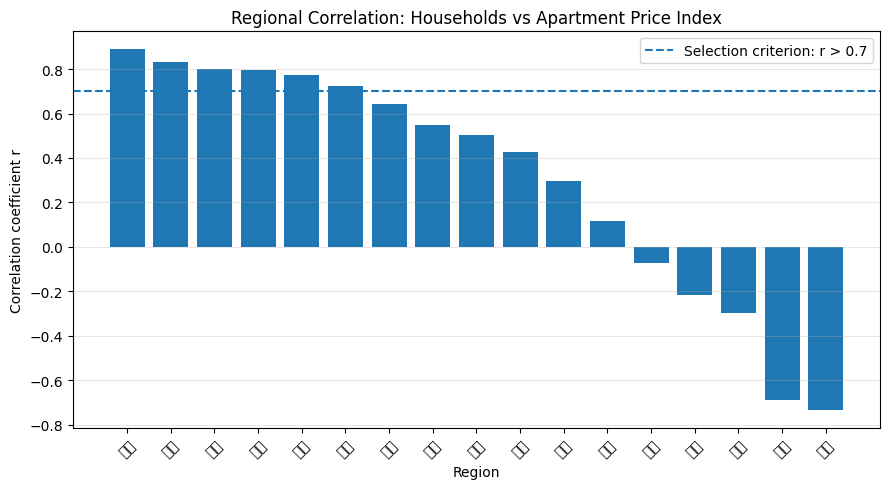

In [ ]:
# Bar graph: regional correlation coefficients

plt.figure(figsize=(9, 5))

region_result_sorted = region_result.sort_values("Correlation_r", ascending=False)

plt.bar(
    region_result_sorted["Region"],
    region_result_sorted["Correlation_r"]
)

plt.axhline(0.7, linestyle="--", linewidth=1.5, label="Selection criterion: r > 0.7")

plt.xlabel("Region")
plt.ylabel("Correlation coefficient r")
plt.title("Regional Correlation: Households vs Apartment Price Index")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("figures/02_region_selection_correlation.png", dpi=300)
plt.show()

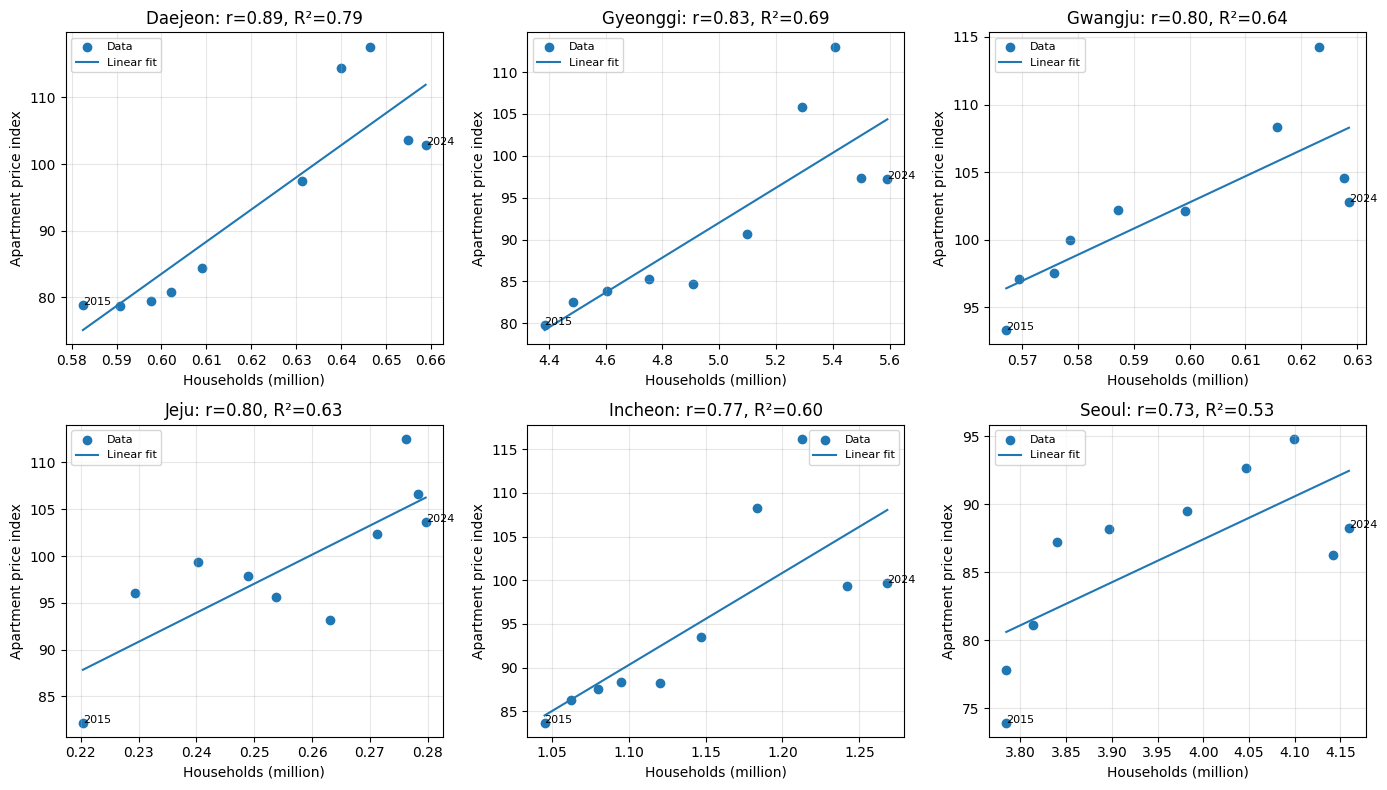

,Region,Correlation_r,R_squared,Slope,Intercept
0,대전,0.888990,0.790304,482.271765,-205.826539
1,경기,0.830134,0.689122,20.840569,-12.187356
2,광주,0.801528,0.642446,193.546913,-13.370317
3,제주,0.796768,0.634839,310.269453,19.473180
4,인천,0.774338,0.599600,105.614027,-25.885992
5,서울,0.725708,0.526652,31.608931,-39.005792


In [ ]:
# Figure 3: Linear regression for selected regions
# Each region has 10 data points from 2015 to 2024

selected = merged[merged["Region"].isin(selected_regions)].copy()

# English labels to avoid Korean font issues in Colab
region_label = {
    "서울": "Seoul",
    "인천": "Incheon",
    "대전": "Daejeon",
    "광주": "Gwangju",
    "경기": "Gyeonggi",
    "제주": "Jeju"
}

n_regions = len(selected_regions)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

regression_summary = []

for i, region in enumerate(selected_regions):
    ax = axes[i]

    temp = selected[selected["Region"] == region].sort_values("Year")

    x = temp["General_Households"] / 1_000_000   # million households
    y = temp["Apartment_Price_Index"]

    # Linear fitting
    a, b = np.polyfit(x, y, 1)
    y_fit = a * x + b

    # R-squared
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Correlation
    r = np.corrcoef(x, y)[0, 1]

    regression_summary.append([
        region,
        r,
        r2,
        a,
        b
    ])

    # Plot data and fitting line
    ax.scatter(x, y, label="Data")
    ax.plot(x, y_fit, label="Linear fit")

    # Mark first and last year
    ax.text(x.iloc[0], y.iloc[0], "2015", fontsize=8)
    ax.text(x.iloc[-1], y.iloc[-1], "2024", fontsize=8)

    label = region_label.get(region, region)
    ax.set_title(f"{label}: r={r:.2f}, R²={r2:.2f}")
    ax.set_xlabel("Households (million)")
    ax.set_ylabel("Apartment price index")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/03_selected_regions_regression.png", dpi=300)
plt.show()

regression_summary = pd.DataFrame(
    regression_summary,
    columns=["Region", "Correlation_r", "R_squared", "Slope", "Intercept"]
)

display(regression_summary)

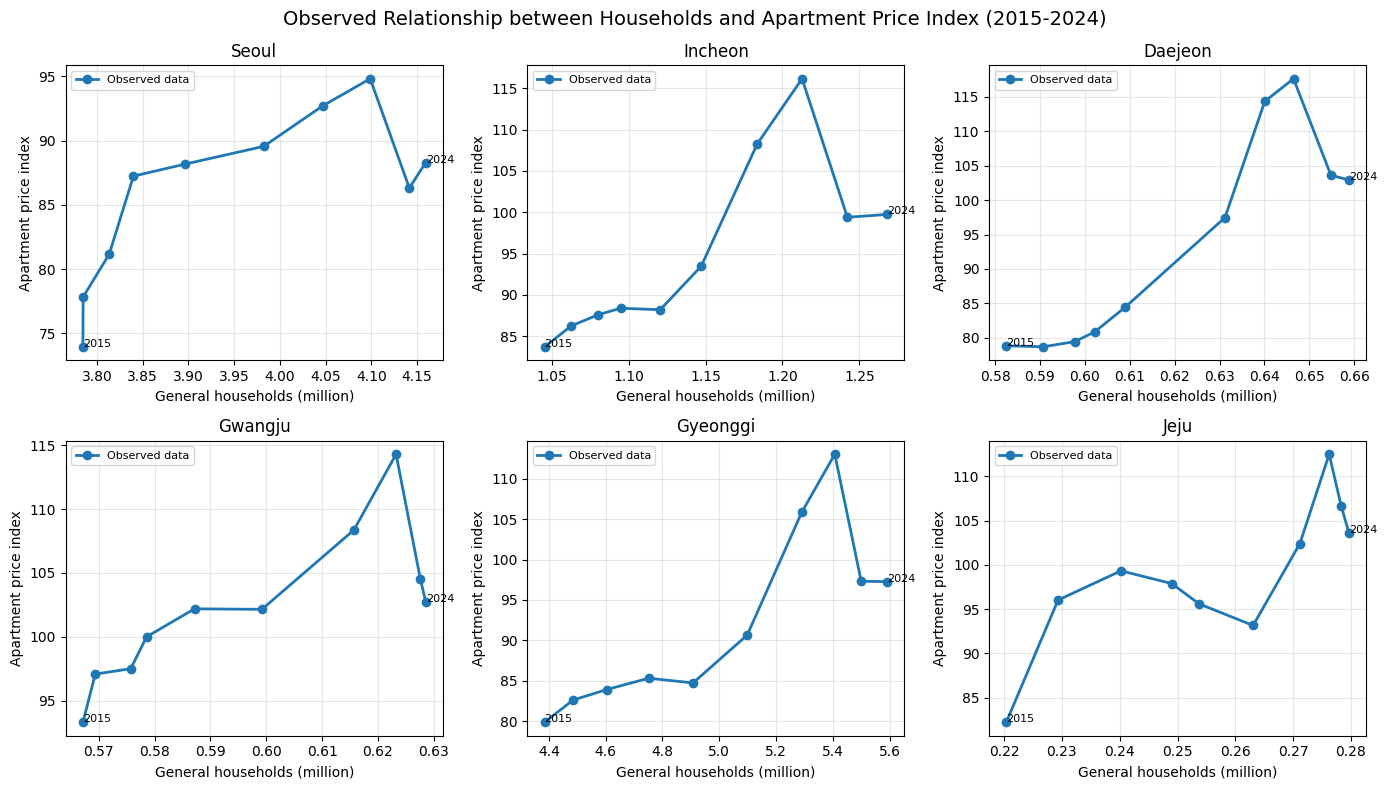

In [14]:
# Figure 4: Observed data for selected regions only
# x = General households
# y = Apartment price index
# Period = 2015-2024
# No Monte Carlo, no prediction

selected_regions = ["서울", "인천", "대전", "광주", "경기", "제주"]

region_label = {
    "서울": "Seoul",
    "인천": "Incheon",
    "대전": "Daejeon",
    "광주": "Gwangju",
    "경기": "Gyeonggi",
    "제주": "Jeju"
}

selected = merged[merged["Region"].isin(selected_regions)].copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, region in enumerate(selected_regions):
    ax = axes[i]

    temp = selected[selected["Region"] == region].sort_values("Year")

    x = temp["General_Households"] / 1_000_000
    y = temp["Apartment_Price_Index"]

    # Observed data only: blue line + blue points
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label="Observed data"
    )

    # Label only first and last year
    ax.text(x.iloc[0], y.iloc[0], "2015", fontsize=8)
    ax.text(x.iloc[-1], y.iloc[-1], "2024", fontsize=8)

    label = region_label.get(region, region)
    ax.set_title(label)
    ax.set_xlabel("General households (million)")
    ax.set_ylabel("Apartment price index")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(
    "Observed Relationship between Households and Apartment Price Index (2015-2024)",
    fontsize=14
)

plt.tight_layout()
plt.savefig("figures/04_observed_selected_regions.png", dpi=300)
plt.show()